In [1]:
import torch
import random
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

In [2]:
# ---------------------------------------------------------------------------*/
# - prepare a dataset

# define known data properties
timeseries_len  = 201
timestep        = 0.001
dataset_dir     = 'cavity/10Hz'

# read data from files
data_train = utils.read_datafile(f'{dataset_dir}/train1', timeseries_len)
data_valid = utils.read_datafile(f'{dataset_dir}/valid', timeseries_len)
data_test = utils.read_datafile(f'{dataset_dir}/test', timeseries_len)

# data channels are expected to contain:
# 1. displacement
# 2. velocity
# 5. rf field gradient
x_dims_n = 2
u_dims_n  = 1

# compile dataset parameters
data_table = [
    ( 'dataset',           'batches',        'timeseries length',          'channels'),
    ('--------',           '-------',        '-----------------',          '--------'),
    (   'train', data_train.shape[0], data_train.shape[1], data_train.shape[2]),
    (   'valid', data_valid.shape[0], data_valid.shape[1], data_valid.shape[2]),
    (    'test',  data_test.shape[0],  data_test.shape[1],  data_test.shape[2]) ]

# print dataset parameters
print('inf >> dataset parameters:')
print('')
for row in data_table:
    print(f'{row[0]:>8} {row[1]:>8} {row[2]:>18} {row[3]:>8}')

inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                201        3
   valid     1000                201        3
    test      500                201        3


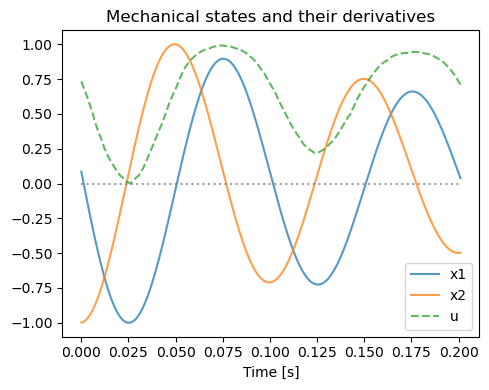

In [3]:
data_i = 144
data_viz = data_train[data_i]
t_viz = torch.linspace(0., timestep*timeseries_len, timeseries_len)
zero_viz = torch.zeros_like(t_viz)

plt.figure(figsize=(5, 4))
plt.title('Mechanical states and their derivatives')
plt.plot(t_viz, data_viz[:, 0], color='tab:blue', alpha=0.75, label='x1')
plt.plot(t_viz, data_viz[:, 1], color='tab:orange', alpha=0.75, label='x2')
plt.plot(t_viz, data_viz[:, 2], color='tab:green', linestyle='dashed', alpha=0.75, label='u')
plt.plot(t_viz, zero_viz, color='tab:gray', linestyle='dotted', alpha=0.75)
plt.legend()
plt.xlabel('Time [s]')
plt.tight_layout()
plt.show()

In [4]:
# ---------------------------------------------------------------------------*/
# - instantiate dynamic mode decomposition

print(f'inf >> number of data dimensions is {x_dims_n}')
print(f'inf >> number of control dimensions is {u_dims_n}')

config = {
    'x_dims_n'              : x_dims_n,
    'u_dims_n'              : u_dims_n,

    'modes'                 : [(2*torch.pi*10., 0.1)],

    'timestep'              : timestep,
    'predict_horizon'       : 51,
    'batch_size'            : 128,
    'loss_w_ae'             : 8e-1,
    'loss_w_lin'            : 1e0,
    'loss_w_pred'           : 1e0,
    'loss_w_params'         : 0,#1e-3,
    'loss_w_phys'           : 8e-8
}

model = care.deep_koopman(config)

inf >> number of data dimensions is 2
inf >> number of control dimensions is 1


inf >> Number of data files for training : 4
inf >> Processing training file number 1
inf >> Processing training file number 2
inf >> Processing training file number 3
inf >> Processing training file number 4


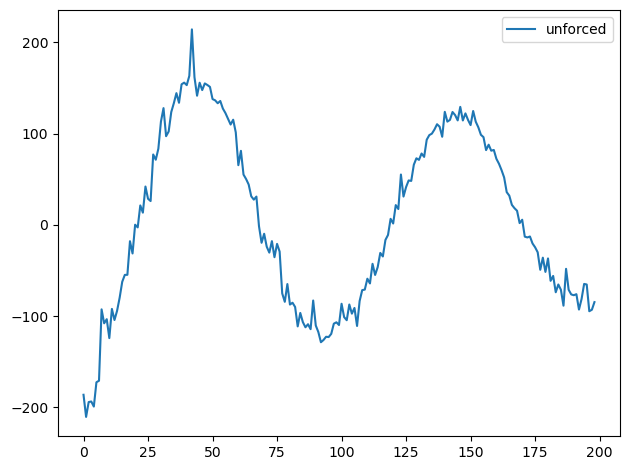

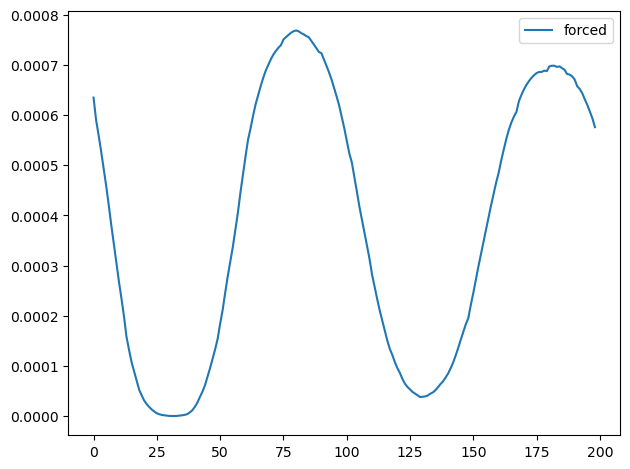

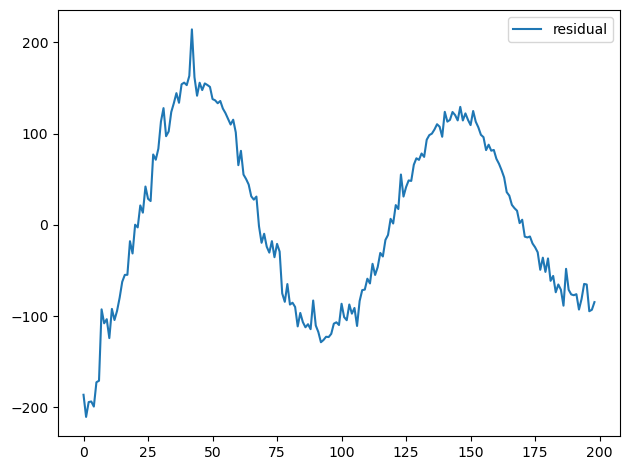

tensor([-2.8821, 63.1526], requires_grad=True)
tensor([-0.0007,  0.0008], requires_grad=True)


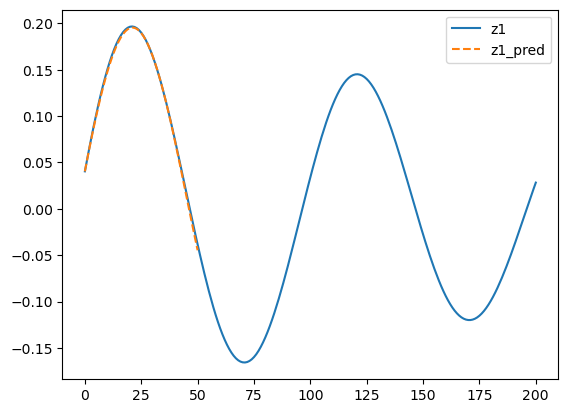

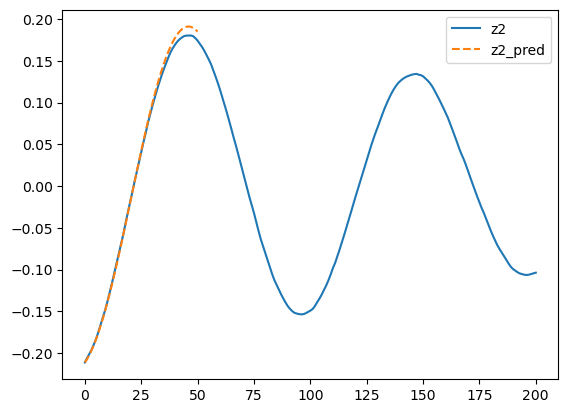

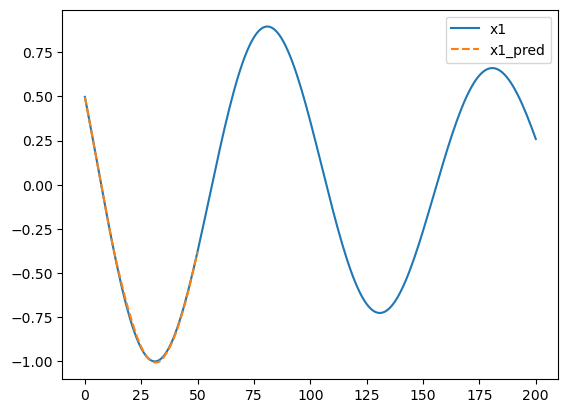

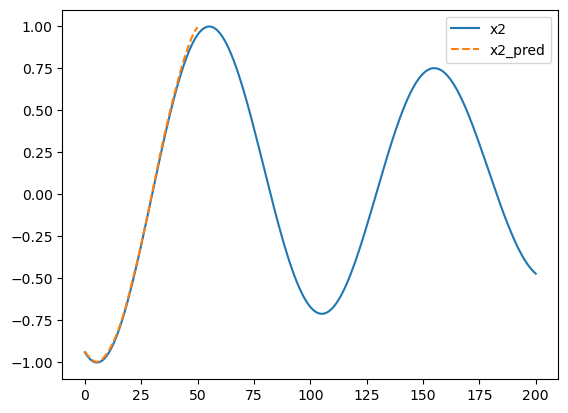

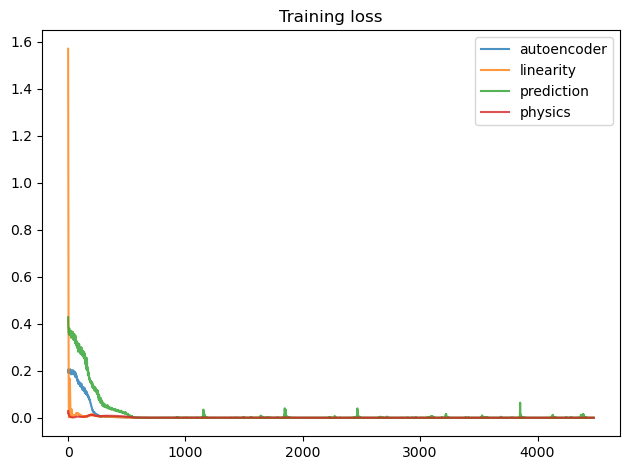

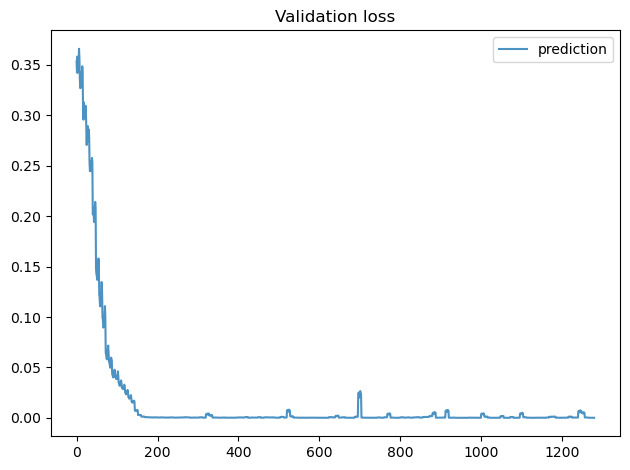

In [5]:
# ---------------------------------------------------------------------------*/
# - training and validation

trainmod_on = True

if trainmod_on:
    batch_size = config['batch_size']

    # --! make validation datasets and loaders
    dataset_valid = torch.utils.data.TensorDataset(data_valid)
    dataloader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size=batch_size, shuffle=False)

    # --! specify optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # --! empty arrays to gather statistics
    loss_train_ae   = []
    loss_train_lin  = []
    loss_train_pred = []
    loss_train_phys = []
    loss_valid_pred = []

    # --! training duration
    datafiles_train_n = 4
    epochs_n          = 40
    print(f"inf >> Number of data files for training : {datafiles_train_n}")

    horizon_valid = config['predict_horizon']

    for datafile_train in range(datafiles_train_n):
        print(f"inf >> Processing training file number {datafile_train + 1}")

        # --! make training datasets and loaders
        data_train = utils.read_datafile(f'{dataset_dir}/train{datafile_train + 1}', timeseries_len)
        dataset_train = torch.utils.data.TensorDataset(data_train)
        dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

        # --! train
        for epoch in range(epochs_n):

            # --! train neural networks
            for this, data in enumerate(dataloader_train):
                x  = data[0][:, :, :x_dims_n]
                u  = data[0][:, :, x_dims_n:]

                optimizer.zero_grad()

                ae_only = False#datafile_train < 2

                # test ~ test ~ test
                #print(len(dataloader_train))
                # 128 -> 27
                # 64 -> 54
                # 256 -> 13
                now = this==27 and epoch==epochs_n-1 and datafile_train==datafiles_train_n-1

                # --! fit a model to training data
                loss, loss_ae, loss_lin, loss_pred, loss_phys = model.fit(x, u, ae_only, now)

                loss.backward()
                optimizer.step()

                with torch.no_grad():
                    loss_train_ae.append(loss_ae)
                    loss_train_lin.append(loss_lin)
                    loss_train_pred.append(loss_pred)
                    loss_train_phys.append(loss_phys)

            # --! validate results
            with torch.no_grad():
                for data in dataloader_valid:
                    x  = data[0][:, :, :x_dims_n]
                    u  = data[0][:, :, x_dims_n:]

                    # --! validate prediction
                    x_pred = model.predict(x, u, horizon_valid)
                    loss_valid_pred.append(torch.mean((x[:, :horizon_valid, :] - x_pred)**2))

    # --! display training statistics
    with torch.no_grad():
        plt.figure()
        plt.title('Training loss')
        plt.plot(loss_train_ae, alpha=0.8, label='autoencoder')
        plt.plot(loss_train_lin, alpha=0.8, label='linearity')
        plt.plot(loss_train_pred, alpha=0.8, label='prediction')
        plt.plot(loss_train_phys, alpha=0.8, label='physics')
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure()
        plt.title('Validation loss')
        plt.plot(loss_valid_pred, alpha=0.8, label='prediction')
        plt.legend()
        plt.tight_layout()
        plt.show()

In [6]:
# --!--------------------------------------------------------------------------
# --! save a trained model

savemod_on = False

if savemod_on:
    torch.save(model, 'data/models/cav10Hz.pt')

inf >> prediction loss in test is 1.092407e-04


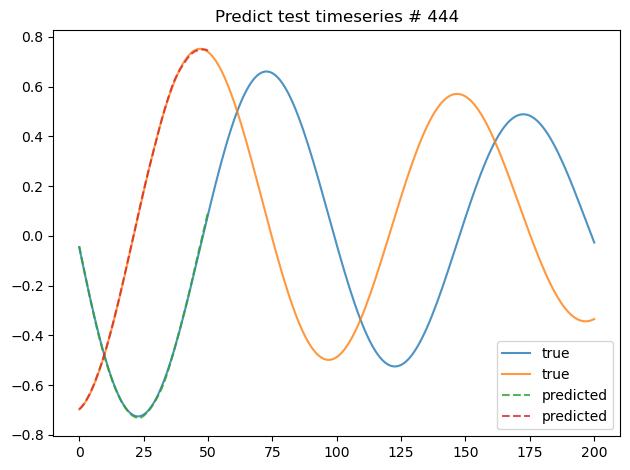

In [7]:
# --!--------------------------------------------------------------------------
# --! model inference for a test

loadmod_on = False

if loadmod_on:
    model = torch.load('data/models/cav10Hz.pt', weights_only=False)

batch_size = config['batch_size']

# --! make validation datasets and loaders
dataset_test = torch.utils.data.TensorDataset(data_test)
dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

horizon_test = config['predict_horizon']
loss_test_pred = []

with torch.no_grad():
    for data in dataloader_test:
        x  = data[0][:, :, :x_dims_n]
        u  = data[0][:, :, x_dims_n:]

        # --! test prediction
        x_pred = model.predict(x, u, horizon_test)
        loss_test_pred.append(torch.mean((x[:, :horizon_test, :] - x_pred)**2))

loss_test_pred_mean = np.mean(loss_test_pred)
print(f'inf >> prediction loss in test is {loss_test_pred_mean:e}')

with torch.no_grad():
    data_i = 444
    data   = data_test[data_i]
    x      = torch.unsqueeze(data[:, :x_dims_n], dim=0)
    u      = torch.unsqueeze(data[:, x_dims_n:], dim=0)
    x_pred = model.predict(x, u, horizon_test)

    x      = torch.squeeze(x, dim=0)
    x_pred = torch.squeeze(x_pred, dim=0)

    plt.figure()
    plt.title(f'Predict test timeseries # {data_i}')
    plt.plot(x, alpha=0.8, label='true')
    plt.plot(x_pred, alpha=0.8, linestyle='dashed', label='predicted')
    plt.legend()
    plt.tight_layout()
    plt.show()